# MAE ENCODER WITH VARIANCE BASED CLASSIFIER

# Imports

In [1]:
import sys
import shutil
from collections import Counter

import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import torch.nn as nn

from transformers import AutoImageProcessor, ViTImageProcessor, ViTMAEModel

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

import json
import os
import random
from tqdm.auto import tqdm



## Config

### Directories

In [3]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    ZIP_SOURCE = "/content/drive/MyDrive/AIgen_Image_Detection_Via_DL_3.5/CLS_Dataset.zip"
    DATASET_ROOT = "/content/Dataset"

    if not os.path.exists(DATASET_ROOT):
        print("Copying zip from Drive to local runtime (faster unzipping)...")

        shutil.copy(ZIP_SOURCE, "/content/Dataset.zip")
        print("Unzipping dataset...")
        shutil.unpack_archive("/content/Dataset.zip", "/content/Dataset")
        print("Done!")
    else:
        print("Dataset already extracted.")
else:
    DEFAULT_ROOT = "E:/pigeon/Documents/ENSF617/AIgen_Image_Detection_Via_DL_3.5/Dataset"
    DATASET_ROOT = os.getenv("DATASET_ROOT", DEFAULT_ROOT)

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
TEST_DIR = os.path.join(DATASET_ROOT, "test")
VAL_DIR = os.path.join(DATASET_ROOT, "val")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying zip from Drive to local runtime (faster unzipping)...
Unzipping dataset...
Done!


In [4]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    MODEL_ZIP = "/content/drive/MyDrive/AIgen_Image_Detection_Via_DL_3.5/myMAE.zip"
    MODEL_ROOT = "/content/myMAE"

    if not os.path.exists(MODEL_ROOT):
        print("Copying model zip to local runtime...")
        shutil.copy(MODEL_ZIP, "/content/myMAE.zip")

        print("Unzipping model...")
        shutil.unpack_archive("/content/myMAE.zip", "/content/myMAE")

        print("Model ready.")
    else:
        print("Model already extracted.")

else:
    MODEL_ROOT = "E:/pigeon/Documents/ENSF617/AIgen_Image_Detection_Via_DL_3.5/models/myMAE"

MODEL_DIR = os.getenv("MODEL_DIR", MODEL_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying model zip to local runtime...
Unzipping model...
Model ready.


### Hyperparameters

In [79]:
DATA_LOADER_BATCH_SIZE = 50
DATA_LOADER_NUM_WORKERS = 2

NUM_EPOCHS = 30
LEARNING_RATE = 3e-4

PATIENCE = 3

# Reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

---

## Data Prepraration

In [80]:
# same processor as the one in MAE_on_FIDD.ipynb
# processor = AutoImageProcessor.from_pretrained("facebook/vit-mae-base")
processor = AutoImageProcessor.from_pretrained(MODEL_DIR)

In [81]:
# ViTMAE expects images normalized / resized via processor
def transform(image):
    return processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

### Datasets & Data Loaders

In [82]:
# Datasets
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(root=VAL_DIR, transform=transform)
test_dataset  = datasets.ImageFolder(root=TEST_DIR, transform=transform)

In [83]:
# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=DATA_LOADER_BATCH_SIZE,
    shuffle=True, # only shuffle training data
    num_workers=DATA_LOADER_NUM_WORKERS,
    persistent_workers=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=DATA_LOADER_BATCH_SIZE,
    shuffle=False,
    num_workers=DATA_LOADER_NUM_WORKERS,
    persistent_workers=True,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=DATA_LOADER_BATCH_SIZE,
    shuffle=False,
    num_workers=DATA_LOADER_NUM_WORKERS,
    persistent_workers=True,
    pin_memory=True
)

# Class mapping check
print("Classes:", train_dataset.classes)
print("Class to idx:", train_dataset.class_to_idx)

FAKE_LABEL = train_dataset.class_to_idx["Fake"]
REAL_LABEL = train_dataset.class_to_idx["Real"]

Classes: ['Fake', 'Real']
Class to idx: {'Fake': 0, 'Real': 1}


## Dataset Size Check

In [84]:
def get_class_counts(dataset):
    # ImageFolder stores labels in dataset.targets
    return Counter(dataset.targets)

train_counts = get_class_counts(train_dataset)
val_counts   = get_class_counts(val_dataset)
test_counts  = get_class_counts(test_dataset)

def map_counts(counts, dataset):
    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
    return {
        idx_to_class[i]: counts.get(i, 0)
        for i in range(len(idx_to_class))
    }
print("\nTrain total:", sum(train_counts.values()))
print("Validation total:", sum(val_counts.values()))
print("Test total:", sum(test_counts.values()))

print("\nTrain class counts:", map_counts(train_counts, train_dataset))
print("Validation class counts:", map_counts(val_counts, val_dataset))
print("Test class counts:", map_counts(test_counts, test_dataset))


Train total: 6000
Validation total: 1500
Test total: 1500

Train class counts: {'Fake': 3000, 'Real': 3000}
Validation class counts: {'Fake': 750, 'Real': 750}
Test class counts: {'Fake': 750, 'Real': 750}


## Checking Device

In [85]:
if torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple GPU
    print("Using MPS (Apple GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")  # NVIDIA GPU
    print("Using CUDA")
else:
    device = torch.device("cpu")   # fallback
    print("Using CPU")

Using CUDA


---

## Model Definition
- Uses pretrained MAE (fine-tuned in MAE_on_FIDD.ipynb) as its encoder
- MLP classifier head

In [86]:
myMAE = ViTMAEModel.from_pretrained(MODEL_DIR)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTMAEModel LOAD REPORT from: /content/myMAE
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_after.weight           | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.value.bias   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.dense.weight              | UNEXPECTED |  | 
decoder.mask_token                                                               | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_before.weight          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.dense.bias                | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attenti

In [87]:
class MAEVarianceClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # Load the pretrained ViT-MAE model as the encoder
        self.encoder = myMAE
        # Freeze the encoder parameters to prevent training
        for param in self.encoder.parameters():
            param.requires_grad = False

        self.hidden_dim = self.encoder.config.hidden_size  # = 768 = the feature dimension

        # MLP head
        self.classifier = nn.Sequential(
          nn.LayerNorm(self.hidden_dim * 2),
          nn.Linear(self.hidden_dim * 2, 512),
          nn.GELU(),
          nn.Dropout(0.2),
          nn.Linear(512, 128),
          nn.GELU(),
          nn.Dropout(0.2),
          nn.Linear(128, num_classes)
        )

    def forward(self, pixel_values, return_features=False):
        outputs = self.encoder(pixel_values=pixel_values)

        patch_embeddings = outputs.last_hidden_state[:, 1:, :]

        mean_vector = patch_embeddings.mean(dim=1)
        var_vector = patch_embeddings.var(dim=1, unbiased=False)

        features = torch.cat([mean_vector, var_vector], dim=1)
        logits = self.classifier(features)

        if return_features:
            return logits, mean_vector, var_vector

        return logits

### Model Initialization

In [88]:
model = MAEVarianceClassifier(num_classes=2) # Binary classification for now
model = model.to(device)

#### Verify encoder is frozen

In [89]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable_params}")
print(f"Total params: {total_params}")

Trainable params: 855938
Total params: 86654594


---
## Training

### Loss + Optimizer + Learning Rate Scheduler
- Only pass **classifier parameters** to optimizer since we do not want to train the encoder.
- This avoids accidentally trying to update the frozen encoder.

In [90]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=LEARNING_RATE
)

# is enough for binary classification, no need for more complex schedulers
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

## Training Helper Function

In [91]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    # tqdm for progress tracking
    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    acc = correct / total

    return avg_loss, acc

## Evaluation Function

In [92]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(dataloader), correct / total

---

## Main Training Loop

In [93]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
counter = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    # ---- Scheduler Step ----
    scheduler.step()

    # ---- Record history ----
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # ---- Logging ----
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}, "
          f"LR={current_lr:.6f}")

    # ---- Early Stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict()
        }, "best_variance_based_model.pt")
    else:
        counter += 1

        if counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

Training:   0%|          | 0/120 [00:00<?, ?it/s]

Epoch 1: Train Loss=0.6507, Train Acc=0.6158, Val Loss=0.6079, Val Acc=0.6647, LR=0.000299


Training:   0%|          | 0/120 [00:00<?, ?it/s]

Epoch 2: Train Loss=0.5412, Train Acc=0.7298, Val Loss=0.4970, Val Acc=0.7567, LR=0.000297


Training:   0%|          | 0/120 [00:00<?, ?it/s]

...

Epoch 22: Train Loss=0.2220, Train Acc=0.9117, Val Loss=0.2794, Val Acc=0.8847, LR=0.000050


Training:   0%|          | 0/120 [00:00<?, ?it/s]

Epoch 23: Train Loss=0.2294, Train Acc=0.9050, Val Loss=0.2549, Val Acc=0.8987, LR=0.000039


Training:   0%|          | 0/120 [00:00<?, ?it/s]

Epoch 24: Train Loss=0.2231, Train Acc=0.9052, Val Loss=0.2531, Val Acc=0.8980, LR=0.000029
Early stopping triggered at epoch 24


### Plot training/validation curves
- Loss and Accuracy

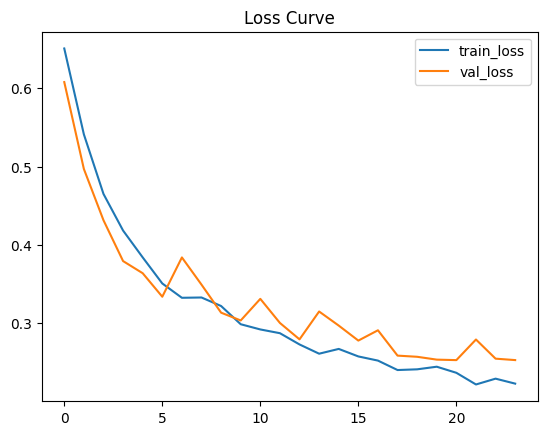

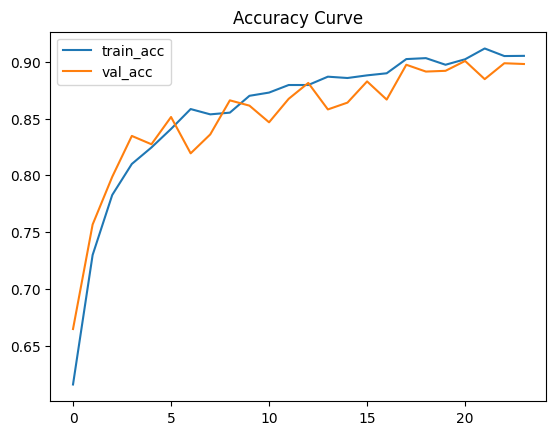

In [94]:
# Loss
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.savefig("loss_curve.png")
plt.show()

# Accuracy
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.legend()
plt.title("Accuracy Curve")
plt.savefig("accuracy_curve.png")
plt.show()

## Testing

In [120]:
checkpoint = torch.load("best_variance_based_model.pt")
# load best model
model.load_state_dict(checkpoint["model"])
model.eval()

MAEVarianceClassifier(
  (encoder): ViTMAEModel(
    (embeddings): ViTMAEEmbeddings(
      (patch_embeddings): ViTMAEPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
    )
    (encoder): ViTMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTMAELayer(
          (attention): ViTMAEAttention(
            (attention): ViTMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTMAEIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_fn): GELUAc

### Inference

In [121]:
all_images = []
y_true = []
y_pred = []
y_prob = []

# feature attribution storage (gradient-based projections)
mean_contribs = []
var_contribs = []

# store feature vectors for histogram
all_mean_vecs = []
all_var_vecs = []

hidden_dim = model.hidden_dim
MID_POINT = hidden_dim  # split point between mean and var

with torch.enable_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # forward
        outputs, mean_vec, var_vec = model(images, return_features=True)

        probs = torch.softmax(outputs, dim=1)[:, FAKE_LABEL]
        preds = (probs > 0.5).long()

        all_images.append(images.cpu())
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.detach().cpu().numpy())

        all_mean_vecs.append(mean_vec.detach().cpu())
        all_var_vecs.append(var_vec.detach().cpu())

        # concatenate features
        features = torch.cat([mean_vec, var_vec], dim=1)

        # enable gradients on features
        features = features.clone().detach().requires_grad_(True)

        # classifier forward
        logits = model.classifier(features)

        # logit difference (fake vs real)
        score = (logits[:, FAKE_LABEL] - logits[:, REAL_LABEL]).sum()

        # backward to get effective weights
        model.zero_grad()
        score.backward()

        w_eff = features.grad  # same shape as features

        # projections
        proj_mean = (features[:, :MID_POINT] * w_eff[:, :MID_POINT]).sum(dim=1)
        proj_var  = (features[:, MID_POINT:] * w_eff[:, MID_POINT:]).sum(dim=1)

        mean_contribs.extend(proj_mean.detach().cpu().numpy())
        var_contribs.extend(proj_var.detach().cpu().numpy())

### Final Resulting Arrays

In [126]:
all_images = torch.cat(all_images, dim=0)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

y_true_bin = (y_true == FAKE_LABEL).astype(int)

# Fearture contribution summary
mean_contrib = np.mean(mean_contribs)
var_contrib = np.mean(var_contribs)

print("Mean feature contribution:", mean_contrib)
print("Variance feature contribution:", var_contrib)

Mean feature contribution: 3.5915804
Variance feature contribution: -3.5915794


### Compute & Save Metrics

In [127]:
metrics = {
    "accuracy": accuracy_score(y_true_bin, y_pred),
    "precision": precision_score(y_true_bin, y_pred),
    "recall": recall_score(y_true_bin, y_pred),
    "f1_score": f1_score(y_true_bin, y_pred),
    "roc_auc": roc_auc_score(y_true_bin, y_prob)
}

print(metrics)

with open("variance_based_test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

{'accuracy': 0.9006666666666666, 'precision': 0.8798988621997471, 'recall': 0.928, 'f1_score': 0.9033095392602206, 'roc_auc': np.float64(0.9683182222222223)}


## ROC Curve & Confusion Matrix

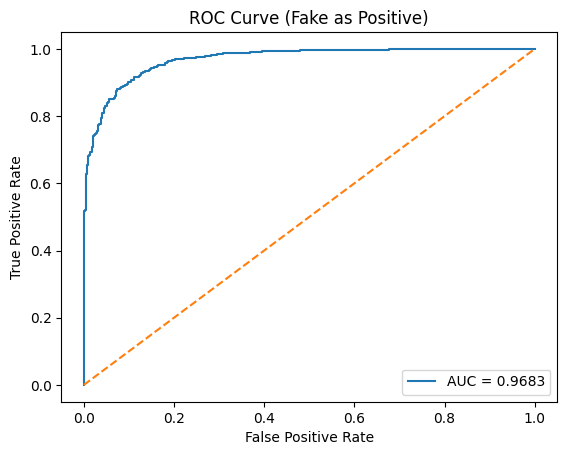

In [128]:
fpr, tpr, _ = roc_curve(y_true_bin, y_prob)  # Fake = positive
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Fake as Positive)")
plt.legend()
plt.savefig("roc_curve.png")
plt.show()

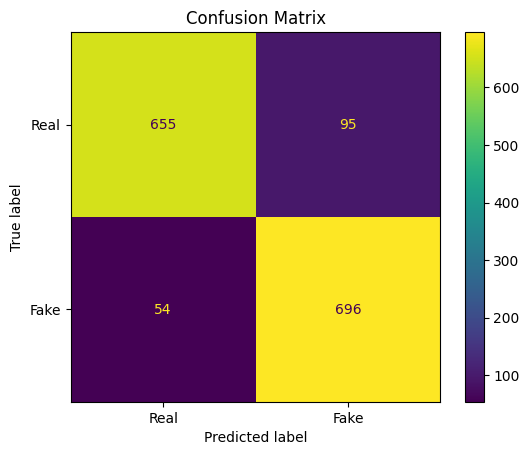

In [129]:
cm = confusion_matrix(y_true_bin, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

## Show Misclassified

In [130]:
real_as_fake_idx = np.where((y_true == REAL_LABEL) & (y_pred == 1))[0]
fake_as_real_idx = np.where((y_true == FAKE_LABEL) & (y_pred == 0))[0]

real_samples = real_as_fake_idx[:5]
fake_samples = fake_as_real_idx[:5]

real_probs = y_prob[real_samples]
fake_probs = y_prob[fake_samples]

In [131]:
# ImageNet denormalization (adjust if you used different mean/std)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def denormalize(img):
    # img: HWC float or CHW torch tensor already converted to HWC numpy
    return img * IMAGENET_STD + IMAGENET_MEAN


def show_and_save_images(indices, probs, title, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    plt.figure(figsize=(12, 3))

    for i, idx in enumerate(indices):
        img = all_images[idx]

        # --- convert to numpy HWC ---
        if torch.is_tensor(img):
            img = img.detach().cpu()
            if img.ndim == 3:  # CHW -> HWC
                img = img.permute(1, 2, 0)
            img = img.numpy()

        elif isinstance(img, np.ndarray):
            if img.ndim == 3 and img.shape[0] in [1, 3]:  # CHW -> HWC
                img = np.transpose(img, (1, 2, 0))

        # --- ensure 3-channel RGB ---
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.shape[-1] == 1:
            img = np.repeat(img, 3, axis=-1)

        img = img.astype(np.float32)

        # --- DENORMALIZE ---
        img = denormalize(img)

        # --- clip only after denormalization ---
        img = np.clip(img, 0.0, 1.0)

        # --- SHOW ---
        plt.subplot(1, len(indices), i + 1)
        plt.imshow(img)
        plt.title(f"{probs[i]:.2f}")
        plt.axis('off')

        # --- SAVE ---
        filename = f"{title.replace(' ', '_')}_{i}_prob_{probs[i]:.3f}.png"
        path = os.path.join(save_dir, filename)
        plt.imsave(path, img)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

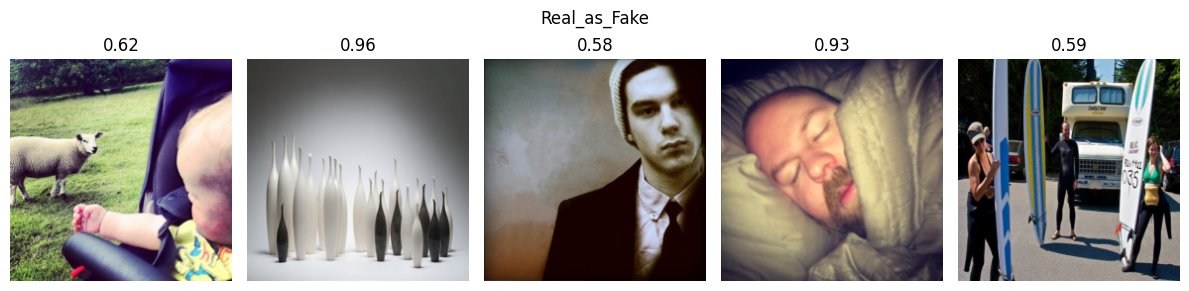

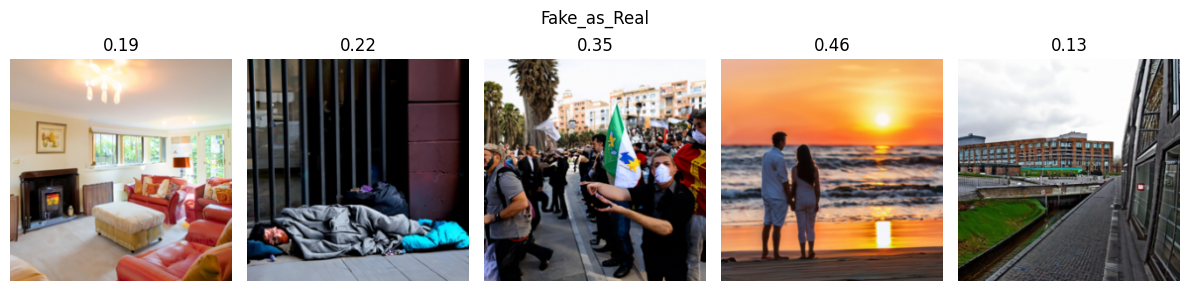

In [106]:
show_and_save_images(
    real_samples,
    real_probs,
    "Real_as_Fake",
    save_dir="outputs/real_as_fake"
)

show_and_save_images(
    fake_samples,
    fake_probs,
    "Fake_as_Real",
    save_dir="outputs/fake_as_real"
)

---
## Gradient-based Mean/Variance Attribution Histogram

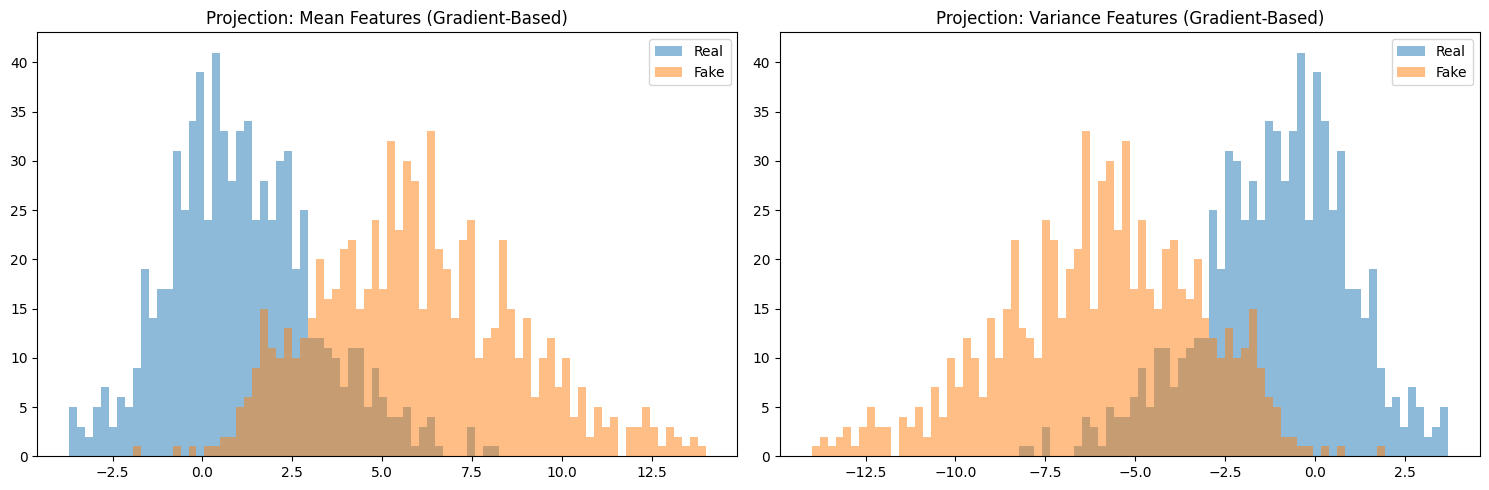

In [134]:
def plot_component(data, labels, title, ax):
    data = np.array(data)
    labels = np.array(labels)

    real = data[labels == REAL_LABEL]
    fake = data[labels == FAKE_LABEL]

    # avoid edge distortion
    lower, upper = np.percentile(data, [1, 99])

    ax.hist(real, bins=80, range=(lower, upper), alpha=0.5, label="Real")
    ax.hist(fake, bins=80, range=(lower, upper), alpha=0.5, label="Fake")
    ax.set_title(title)
    ax.legend()

# Ensure alignment
labels = np.array(y_true)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

plot_component(mean_contribs, labels, "Projection: Mean Features (Gradient-Based)", ax1)
plot_component(var_contribs, labels, "Projection: Variance Features (Gradient-Based)", ax2)

plt.tight_layout()
plt.savefig("gradient_based_histograms.png")
plt.show()
